# Pipeline Comparison – Tìm Scaling Tốt Nhất cho Clustering
**Metric:** Silhouette Score | **Model:** KMeans | **PCA:** standard

## 0. Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')


## 1. Load dữ liệu
> File đã có: A (wor+log+standard), B (wor+log+standard). Các nhóm C, D, E chưa xử lý.

In [16]:
df = pd.read_csv('model_features_transformed.csv') # standardize A , B 

print(df.shape)
df.head(3)


(5089, 60)


,handleName,followerCnt,startingRate100k,recommendRate100k,followersGrowthRateRank,avgSixSecondsViewsRateRank,medianViewsRank,videoCompleteRateRank,engagementRateRank,avgSixSecondsViewsBenchMarkViews,...,Food,Sports,total_views_recent,total_hearts_recent,total_comments_recent,median_view_recent,max_view_recent,cov_view_recent,burstiness_recent,recency_days_recent
0,nguyen_huynh_tien,2.467623,1.551280,1.206644,0.002100,0.7786,0.6287,0.325691,0.0100,0.4604,...,0,0,-0.340921,0.359238,0.315830,0.036979,-0.340029,0.956610,0.160784,-0.737646
1,khuyenduong299,1.927133,-0.737146,1.501161,0.747853,0.8526,0.8090,0.588344,0.2832,0.4607,...,0,0,2.102047,2.356263,2.573223,1.993098,1.848568,1.119467,-0.008681,0.102047
2,n.huyen2k4,2.108710,-0.737146,1.254545,0.049416,0.7579,0.4392,0.341017,0.0127,0.4604,...,0,0,0.320244,0.595628,0.439760,0.954022,-0.369363,0.511231,-0.414296,-0.170552


In [17]:
handle_col = df['handleName']
df = df.drop(columns=['handleName'])

## 2. Khai báo nhóm cột

In [ ]:
# ── Đã xử lý → passthrough toàn bộ pipeline ─────────────────────────────
cols_A = [   # log + scaled
    'startingRate100k', 'recommendRate100k', 'total_views_recent',
    'max_view_recent', 'total_hearts_recent', 'followerCnt',
    'median_view_recent', 'medianViews', 'medianBenchMarkViews',
    'total_comments_recent', 'recency_days_recent', 'followersGrowthRate'
]
cols_B = [   # log + scaled
    'broadcastingScore', 'collaborationScore', 'commercialScore', 
]




# ── Chưa xử lý ───────────────────────────────────────────────────────────
cols_D = [   # rank = > rates
    'followersGrowthRateRank', 'avgSixSecondsViewsRateRank',
    'medianViewsRank', 'videoCompleteRateRank', 'engagementRateRank'
]
cols_E = [   # binary one-hot
    'Beauty', 'Education', 'Entertainment', 'Food', 'Sports'
]

# ── Nhóm C: rate/tỉ lệ — tách skewed vs normal ───────────────────────────
cols_C_skewed = [   # skew > 2, cần Robust
    'country_KR', 'country_JP', 'country_TW', 'country_KH',
    'country_PH', 'country_TH', 'country_ID', 'country_US', 'country_MM',
    'age_55+', 'age_Other', 'age_45-54', 'device_Other'
]
cols_C_normal = [   # skew <= 2, không cần scale
    'active_active', 'active_inactive',
    'age_18-24', 'age_25-34', 'age_13-17', 'age_35-44',
    'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
    'device_XIAOMI', 'device_VIVO',
    'gender_Female', 'gender_Male', 'country_VN'
]
cols_C_bench = [   # benchmark rates
    'avgSixSecondsViewsBenchMarkViews', 'engagementRateBenchMark', 'medianBenchMarkViews',
]
cols_C_perf = [    # performance rates
    'avgSixSecondsViewsRate', 'videoCompleteRate',
    'engagementRate', 
]
cols_C_other = [   # recent
    'cov_view_recent',
    'burstiness_recent',

]





cols_C_all     = cols_C_skewed + cols_C_normal + cols_C_bench + cols_C_perf + cols_C_other
cols_passthru  = cols_A + cols_B + cols_E  # luôn passthrough

cols_C_tc = cols_C_normal + cols_C_bench + cols_C_perf

cols_C_tc2 = cols_C_bench + cols_C_perf

# Kiểm tra tất cả cột có trong df không
all_cols = cols_A + cols_B + cols_D + cols_E + cols_C_all
missing  = [c for c in all_cols if c not in df.columns]
print(f"Cột thiếu: {missing if missing else 'Không có'}")
print(f"Tổng cột dùng: {len(all_cols)}")


Cột thiếu: Không có
Tổng cột dùng: 60


In [19]:
def column_stats(df):
    stats = []

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            s = df[col].dropna()

            stats.append({
                'column': col,
                'min': s.min(),
                'max': s.max(),
                'mean': s.mean(),
                'median': s.median(),
                'std': s.std(),
                'skew': s.skew(),
                'kurtosis': s.kurt(),
                'q1': s.quantile(0.25),
                'q3': s.quantile(0.75),
                'iqr': s.quantile(0.75) - s.quantile(0.25),
                'zero_ratio': (s == 0).mean(),
                'unique': s.nunique()
            })

    return pd.DataFrame(stats).sort_values(by='skew', ascending=False)



In [20]:
# stats_df = column_stats(df)
# stats_df.to_csv('feature_stats_transformed_check.csv', index=False)

## 3. Định nghĩa 6 Pipeline

| Pipeline | C_skewed | C_normal | C_bench/perf | D (rank) | Ý tưởng |
|----------|----------|----------|--------------|----------|---------|
| P1 | Robust | Robust | Robust | Robust | Scale toàn bộ C+D |
| P2 | Std | Std | Std | Std | Std toàn bộ C+D |
| P3 | pass | pass | pass | pass | Baseline – không động gì |
| P5 | MinMax | MinMax | MinMax | MinMax | Đưa C+D về [0,1] |
| P6 | Robust | MinMax  | MinMax  | MinMax  | scale C, D |
| P7 | **Robust** | pass | pass | pass | Chỉ scale C có skew>2 |


In [21]:
def make_pipeline(name):
    """Trả về ColumnTransformer theo tên pipeline."""

    pass_always = [(c, 'passthrough') for c in cols_passthru if c in df.columns]

    if name == 'P1':
        return ColumnTransformer([
            ('rob_C',  RobustScaler(), [c for c in cols_C_all if c in df.columns]),
            ('rob_D',  RobustScaler(), [c for c in cols_D     if c in df.columns]),
        ], remainder='passthrough')

    elif name == 'P2':
        return ColumnTransformer([
            ('std_C',  StandardScaler(), [c for c in cols_C_all if c in df.columns]),
            ('std_D',  StandardScaler(), [c for c in cols_D     if c in df.columns]),
        ], remainder='passthrough')

    elif name == 'P3':
        # Baseline: không scale thêm gì
        return ColumnTransformer([
            ('pass_all', 'passthrough',
             [c for c in cols_C_all + cols_D + cols_passthru if c in df.columns])
        ])

    elif name == 'P5':
        return ColumnTransformer([
            ('mm_C',   MinMaxScaler(), [c for c in cols_C_all if c in df.columns]),
            ('mm_D',   MinMaxScaler(), [c for c in cols_D     if c in df.columns]),
        ], remainder='passthrough')

    elif name == 'P6':
        return ColumnTransformer([
            ('rob_C',  RobustScaler(), [c for c in cols_C_skewed if c in df.columns]),
            ('mm_D',   MinMaxScaler(), [c for c in cols_D     if c in df.columns]),
            ('mm_C_tc', MinMaxScaler(), [c for c in cols_C_tc if c in df.columns])
        ], remainder='passthrough')

    elif name == 'P7':
        return ColumnTransformer([
            ('rob_Csk', RobustScaler(),
             [c for c in cols_C_skewed if c in df.columns]),
        ], remainder='passthrough')

    elif name == 'P8':
        return ColumnTransformer([
            ('rob_C',  RobustScaler(), [c for c in cols_C_skewed if c in df.columns]),
            ('std_C',  StandardScaler(), [c for c in cols_D     if c in df.columns]),
            ('std_D',  StandardScaler(), [c for c in cols_C_tc if c in df.columns])
        ], remainder='passthrough')

    elif name == 'P9':
        return ColumnTransformer([
            ('rob_C',  RobustScaler(), [c for c in cols_C_skewed if c in df.columns]),
            ('std_C',  StandardScaler(), [c for c in cols_D     if c in df.columns]),
            ('std_D',  StandardScaler(), [c for c in cols_C_tc2 if c in df.columns])
        ], remainder='passthrough')
        
    raise ValueError(f"Unknown pipeline: {name}")

print("Pipelines định nghĩa xong: P1, P2, P3, P5, P6, P7, P8, P9")


Pipelines định nghĩa xong: P1, P2, P3, P5, P6, P7, P8, P9


## 4. Cấu hình PCA
> Dùng chung một cấu hình để so sánh pipeline công bằng.

In [22]:
PCA_NDIM  = 0.95    # ← tùy chỉnh
K_RANGE    = range(2, 15)
PIPELINE_NAMES = ['P1', 'P6', 'P7','P8', 'P9']


## 5. So sánh Pipeline × K – Silhouette Score

In [23]:
records = []

for p_name in PIPELINE_NAMES:
    ct       = make_pipeline(p_name)
    X_scaled = ct.fit_transform(df)
    print(X_scaled.shape)
    pca     = PCA(n_components=PCA_NDIM, random_state=42)
    X_pca   = pca.fit_transform(X_scaled)
    
    for k in K_RANGE:
        labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_pca)
        sil = silhouette_score(X_pca, labels)
        dbi = davies_bouldin_score(X_pca, labels)
        chi = calinski_harabasz_score(X_pca, labels)
        records.append({
            'pipeline': p_name, 'k': k,
            'silhouette': round(sil, 4),
            'DBI':        round(dbi, 4),
            'CHI':        round(chi, 2),
        })
    print(f"  {p_name} xong")


df_results = pd.DataFrame(records)
print("\n── Silhouette Score (pipeline × k) ─────────────────────────────────")
print(df_results.pivot(index='pipeline', columns='k', values='silhouette').to_string())


(5089, 59)
  P1 xong
(5089, 59)
  P6 xong
(5089, 59)
  P7 xong
(5089, 59)
  P8 xong
(5089, 59)
  P9 xong

── Silhouette Score (pipeline × k) ─────────────────────────────────
k             2       3       4       5       6       7       8       9       10      11      12      13      14
pipeline                                                                                                        
P1        0.5461  0.5978  0.6050  0.5657  0.5758  0.5839  0.5939  0.5819  0.5771  0.4738  0.5757  0.4778  0.4842
P6        0.5723  0.6269  0.6343  0.6021  0.6168  0.6236  0.6338  0.6242  0.6198  0.6210  0.6253  0.6223  0.6221
P7        0.5722  0.6267  0.6341  0.6039  0.6169  0.6224  0.6336  0.6342  0.6196  0.6208  0.5632  0.6220  0.6265
P8        0.5249  0.5742  0.5811  0.5338  0.5439  0.5512  0.5605  0.5490  0.5417  0.5392  0.4280  0.4312  0.2464
P9        0.5488  0.6005  0.6077  0.5680  0.5795  0.5872  0.5992  0.5851  0.5797  0.5800  0.5713  0.4797  0.4854


## 6. Pipeline & K tốt nhất

In [24]:
best_row = df_results.loc[df_results['silhouette'].idxmax()]
print(f"Best pipeline : {best_row['pipeline']}")
print(f"Best k        : {int(best_row['k'])}")
print(f"Silhouette    : {best_row['silhouette']:.4f}")
print(f"DBI           : {best_row['DBI']:.4f}  (nhỏ hơn = tốt hơn)")
print(f"CHI           : {best_row['CHI']:.2f}  (lớn hơn = tốt hơn)")


Best pipeline : P6
Best k        : 4
Silhouette    : 0.6343
DBI           : 0.6776  (nhỏ hơn = tốt hơn)
CHI           : 2719.68  (lớn hơn = tốt hơn)


## X. Lưu dữ liệu đã transform theo Pipeline
> Lưu P1, P6, P7 thành 3 file CSV riêng biệt.

In [45]:
# Lưu P1, P6, P7 thành 3 file CSV
for p_name in ['P6']:
    ct       = make_pipeline(p_name)
    X_scaled = ct.fit_transform(df)
    
    # Lấy tên cột từ transformer
    col_names = df.columns.tolist()
    
    # Chuyển về DataFrame với tên cột gốc
    df_scaled = pd.DataFrame(X_scaled, columns=col_names[:X_scaled.shape[1]])
    
    
    df_save = pd.concat([df_scaled, handle_col], axis=1)
    
    # Lưu file
    filename = f'pipeline_{p_name}_scaled.csv'
    df_save.to_csv(filename, index=False)
    print(f"Đã lưu: {filename} - shape: {df_save.shape}")

Đã lưu: pipeline_P6_scaled.csv - shape: (5089, 60)


## 7. Heatmap Silhouette Score

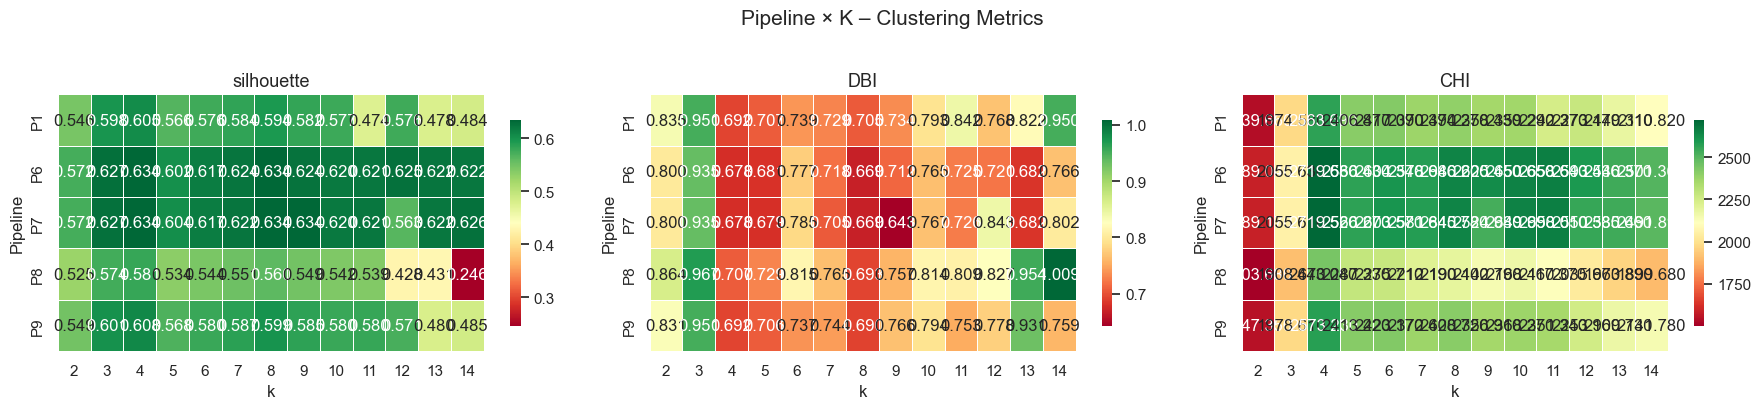

In [26]:
pivot_sil = df_results.pivot(index='pipeline', columns='k', values='silhouette')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, metric in zip(axes, ['silhouette', 'DBI', 'CHI']):
    piv = df_results.pivot(index='pipeline', columns='k', values=metric)
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='RdYlGn',
                ax=ax, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel('k')
    ax.set_ylabel('Pipeline')

plt.suptitle('Pipeline × K – Clustering Metrics', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## 8. Silhouette Score theo k cho từng pipeline

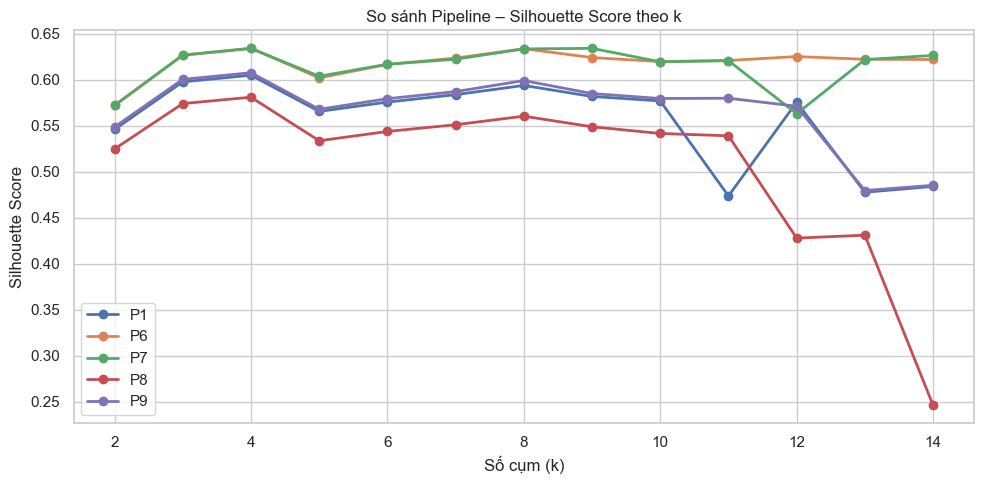

In [27]:
plt.figure(figsize=(10, 5))
for p in PIPELINE_NAMES:
    sub = df_results[df_results['pipeline'] == p]
    plt.plot(sub['k'], sub['silhouette'], marker='o', label=p, linewidth=2)

plt.xlabel('Số cụm (k)')
plt.ylabel('Silhouette Score')
plt.title('So sánh Pipeline – Silhouette Score theo k')
plt.legend()
plt.tight_layout()
plt.show()


## 10. Trực quan hóa PCA clusters cho từng Pipeline
> Dùng k tốt nhất để vẽ biểu đồ scatter 2D (PC1 vs PC2).

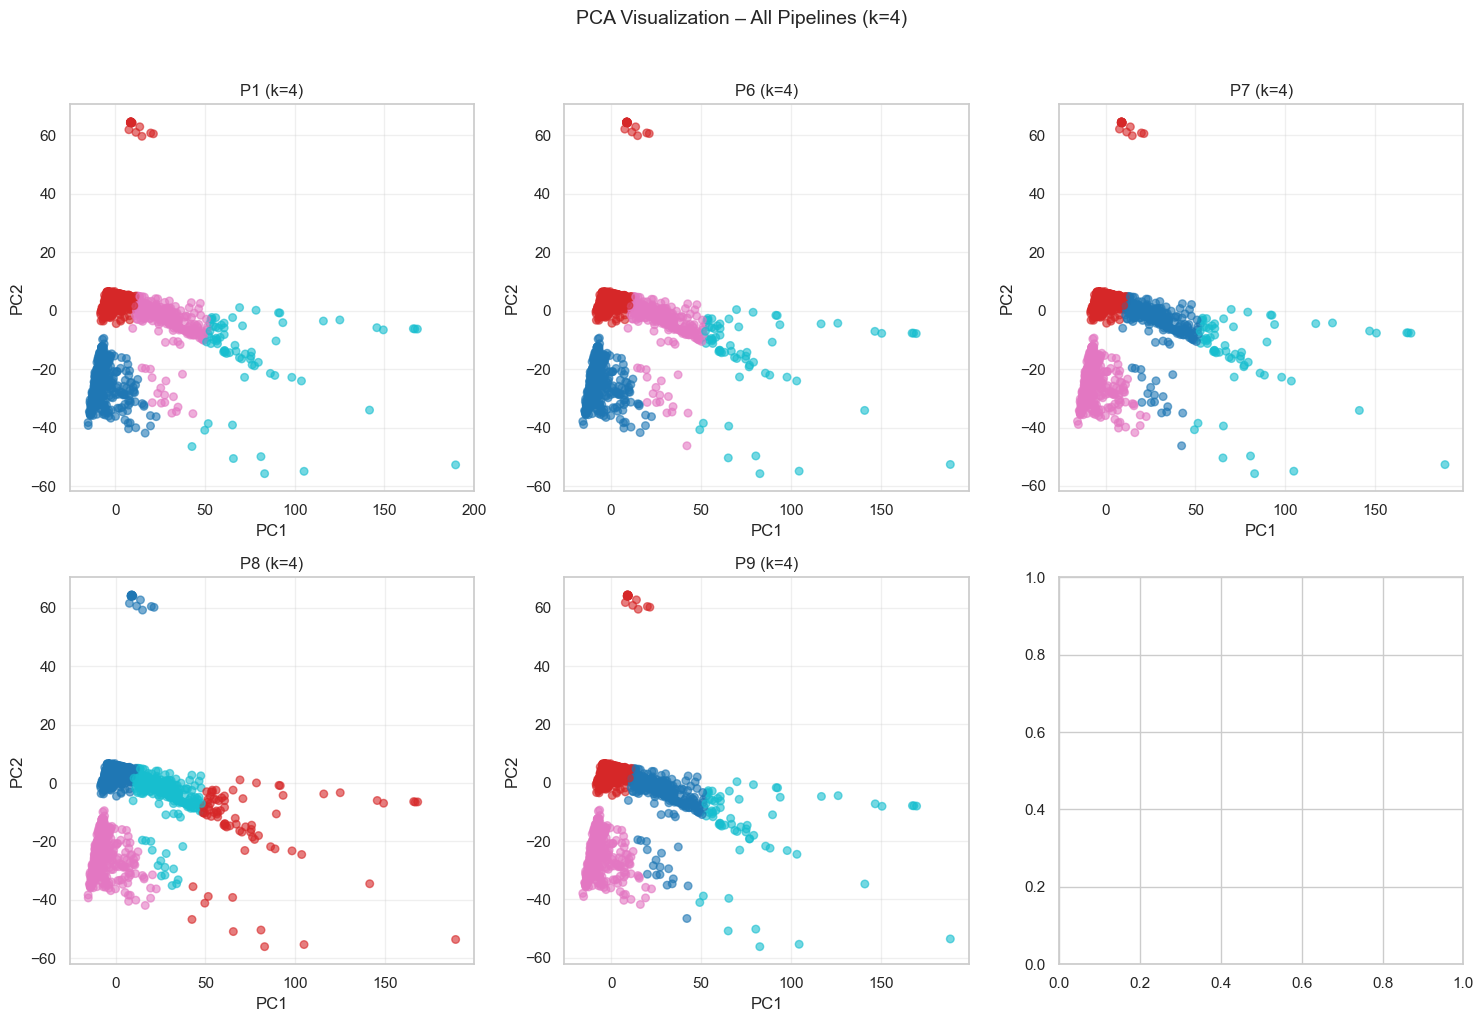

Đã vẽ PCA clusters cho 5 pipelines với k=4


In [28]:
# Dùng k tốt nhất từ kết quả
best_k = int(best_row['k'])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, p_name in enumerate(PIPELINE_NAMES):
    ct       = make_pipeline(p_name)
    X_scaled = ct.fit_transform(df)

    pca     = PCA(n_components=2, random_state=42)
    X_2d    = pca.fit_transform(X_scaled)

    labels  = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_2d)

    scatter = axes[idx].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', alpha=0.6, s=30)
    axes[idx].set_xlabel('PC1')
    axes[idx].set_ylabel('PC2')
    axes[idx].set_title(f'{p_name} (k={best_k})')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle(f'PCA Visualization – All Pipelines (k={best_k})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Đã vẽ PCA clusters cho {len(PIPELINE_NAMES)} pipelines với k={best_k}")


── Silhouette Score (pipeline × k) ─────────────────────────────────
k              2       3       4       5       6       7
pipeline                                                
P1        0.4112  0.4450  0.4992  0.5079  0.5327  0.5385
P6        0.4114  0.4453  0.4533  0.5082  0.5330  0.5387
P7        0.4193  0.4538  0.4619  0.5192  0.5447  0.5544


| Pipeline | C_skewed | C_normal | C_bench/perf | D (rank) | Ý tưởng |
|----------|----------|----------|--------------|----------|---------|
| P1 |         Robust | Robust    | Robust |      Robust    | Scale toàn bộ C+D |
| P6 |          Robust | MinMax   | MinMax  |      MinMax  | scale C, giữ D |
| P7 |          Robust | pass     | pass    |       pass    | Chỉ scale C có skew>2 |




In [29]:
skew_C = df[cols_C_all].skew().sort_values(ascending=False)
skew_df = pd.DataFrame({'skew': skew_C.round(3)})
skew_df['nhóm'] = skew_df.index.map(
    lambda c: 'C_skewed (>2)' if c in cols_C_skewed else 'C_normal'
)
skew_df['flag'] = skew_df['skew'].apply(
    lambda s: '⚠️ cần check' if (abs(s) > 2 and skew_df.loc[
        skew_df['skew'] == s].index[0] not in cols_C_skewed) else ''
)
print(skew_df.to_string())
print(f"\nSố cột skew > 2 thực tế : {(skew_C.abs() > 2).sum()}")
print(f"Số cột trong cols_C_skewed: {len(cols_C_skewed)}")


                                    skew           nhóm          flag
country_KR                        32.311  C_skewed (>2)              
country_JP                        19.471  C_skewed (>2)              
country_TW                        17.634  C_skewed (>2)              
country_KH                        15.099  C_skewed (>2)              
country_PH                         9.948  C_skewed (>2)              
country_TH                         9.429  C_skewed (>2)              
country_ID                         7.851  C_skewed (>2)              
country_US                         7.708  C_skewed (>2)              
country_MM                         5.768  C_skewed (>2)              
engagementRate                     4.188       C_normal  ⚠️ cần check
age_55+                            3.188  C_skewed (>2)              
age_Other                          3.152  C_skewed (>2)              
age_45-54                          2.550  C_skewed (>2)              
device_Other        